# INF2005 steganography demonstration

This notebook sends one message through PNG and WAV carriers. A sender embeds and
signs it. A receiver uses the stego file and public key to verify it.

## Setup

`samples/Banana.png` is the cover image. Generated files go to a temporary
directory and are removed at the end.

In [1]:
import sys
import tempfile
import wave
from datetime import datetime, timezone
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path):
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview


def show_panels(panels, scale=1, gap=16, background="white"):
    font = ImageFont.load_default()
    prepared = []
    for image, label in panels:
        image = image.convert("RGB")
        image = image.resize((image.width * scale, image.height * scale), Image.Resampling.NEAREST)
        prepared.append((image, str(label)))
    label_height = max(font.getbbox(label)[3] - font.getbbox(label)[1] for _, label in prepared)
    panel_top = label_height + 8
    canvas_width = sum(image.width for image, _ in prepared) + gap * (len(prepared) - 1)
    canvas_height = panel_top + max(image.height for image, _ in prepared) + 2
    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)
    x = 0
    for image, label in prepared:
        draw.text((x, 2), label, fill="black", font=font)
        canvas.paste(image, (x, panel_top))
        draw.rectangle((x, panel_top, x + image.width - 1, panel_top + image.height - 1), outline="black", width=1)
        x += image.width + gap
    return canvas

print(f"Temporary demonstration files: {DEMO_DIR}")
print(f"Sample cover: {sample_png_path}")

Temporary demonstration files: /tmp/inf2005-demo-o5d5azk3
Sample cover: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png


## Sender

The sender loads a cover, chooses embedding settings, signs a message, and writes
a stego file.

### Load the cover image

The media adapter accepts this RGB PNG. The display is smaller, but encoding uses
the full array.

Input path: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png
Array shape: (1568, 1280, 3)
Array dtype: uint8


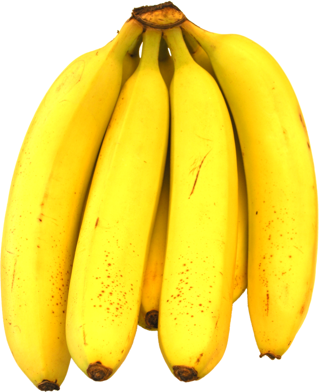

In [2]:
cover_array = load_png_from_path(sample_png_path)
cover_carrier = rgb_array_to_carrier(cover_array)
cover_image = Image.fromarray(cover_array, mode="RGB")
cover_display = cover_image.copy()
cover_display.thumbnail((320, 392))
print("Input path:", sample_png_path)
print("Array shape:", cover_array.shape)
print("Array dtype:", cover_array.dtype)
display(cover_display)

### Choose the message and embedding settings

A carrier unit is one byte used for embedding. The LSB count (`k`) is the number
of low bits used in each unit. The start unit marks where the packet begins.

The image provides 6,021,120 carrier units. The packet uses a textured banana
region rather than the white background, so the changes can be measured.

In [3]:
private_key, public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
save_rsa_public_key_pem(public_key, public_key_path)
start_unit = 2997120
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"
print(f"Carrier units: {cover_array.shape[1]}*{cover_array.shape[0]}*{cover_array.shape[2]} = {cover_carrier.size}")
print(f"Capacity at k={lsb_count}: {cover_carrier.size * lsb_count} bits ({cover_carrier.size * lsb_count // 8} bytes before packet overhead)")
print("Start unit:", start_unit)
print("LSB count:", lsb_count)
print("Message bytes:", image_message)
print("Metadata:", image_metadata)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))

Carrier units: 1280*1568*3 = 6021120
Capacity at k=3: 18063360 bits (2257920 bytes before packet overhead)
Start unit: 2997120
LSB count: 3
Message bytes: b'INF2005 end-to-end image demonstration'
Metadata: b'kind=png;flow=sender-receiver'
Public-key fingerprint: SHA256:0a0X1ga6KsLvAhUFv8lff2WpqAYCO2m5X+B7QTMIkqI


### Embed the message

`encode_png` writes the signed packet and returns its layout and payload.

In [4]:
png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)

### Inspect the packet

Here is what the encoder produced: where the packet sits and what it contains. A
footprint is the range of carrier units used by the packet. The media hash is a
digest of the carrier with the embedded low bits masked out.

In [5]:
print("Layout.start_unit:", png_layout.start_unit)
print("Layout.lsb_count:", png_layout.lsb_count)
print("Layout.payload_length:", png_layout.payload_length)
print("Layout.footprint:", png_layout.footprint)
print("Layout.pad_bits:", png_layout.pad_bits)
print("Payload.media_id:", png_payload.media_id)
print("Payload.timestamp (integer):", png_payload.timestamp)
print("Payload.timestamp (UTC):", datetime.fromtimestamp(png_payload.timestamp, timezone.utc).isoformat())
print("Payload.nonce (hex):", png_payload.nonce.hex())
print("Payload.media_hash (hex):", png_payload.media_hash.hex())
print("Payload.user_payload:", png_payload.user_payload)
print("Payload.metadata:", png_payload.metadata)
png_payload_bytes = serialize_payload(png_payload)
print("Serialized payload hexdump:", png_payload_bytes.hex(" "))

Layout.start_unit: 2997120
Layout.lsb_count: 3
Layout.payload_length: 168
Layout.footprint: 1192
Layout.pad_bits: 0
Payload.media_id: IMG-e7cafaeaec5f8e02210f1511dcdd4244
Payload.timestamp (integer): 1789209572
Payload.timestamp (UTC): 2026-09-12T10:39:32+00:00
Payload.nonce (hex): b9d5f81251112c543b2ef0f52e6be629
Payload.media_hash (hex): 9555b942143cb5066a1313eb150e893f6d3b0915e0f64e4df0380027ba1d12da
Payload.user_payload: b'INF2005 end-to-end image demonstration'
Payload.metadata: b'kind=png;flow=sender-receiver'
Serialized payload hexdump: 24 49 4d 47 2d 65 37 63 61 66 61 65 61 65 63 35 66 38 65 30 32 32 31 30 66 31 35 31 31 64 63 64 64 34 32 34 34 00 00 00 00 6a a5 2b e4 b9 d5 f8 12 51 11 2c 54 3b 2e f0 f5 2e 6b e6 29 95 55 b9 42 14 3c b5 06 6a 13 13 eb 15 0e 89 3f 6d 3b 09 15 e0 f6 4e 4d f0 38 00 27 ba 1d 12 da 00 00 00 26 49 4e 46 32 30 30 35 20 65 6e 64 2d 74 6f 2d 65 6e 64 20 69 6d 61 67 65 20 64 65 6d 6f 6e 73 74 72 61 74 69 6f 6e 00 00 00 1d 6b 69 6e 64 3d 70 6e 67 3b 66 6c 

### What the signature covers

The signed bytes begin with the ASCII domain tag `INF2005-ACW1\0SIGN\0`. They
then contain the protocol version, LSB count, media code, total units, start unit,
footprint, payload length, media context, and payload. Because the geometry is
signed, moving the packet invalidates the signature even when its payload is
unchanged.

In [6]:
# RE-DERIVED FOR DISPLAY ONLY; encode_png produced the signature internally.
# encode_png does not return its media context, so this adapter call is unavoidable.
png_signed_input = encode_signing_input(
    IMAGE_MEDIA_CODE,
    encode_png_media_context(cover_array.shape, cover_carrier.size),
    png_layout,
    png_payload_bytes,
)
print("Signed-input length:", len(png_signed_input))
print("Signed-input first 96 bytes:", png_signed_input[:96].hex(" "))

Signed-input length: 225
Signed-input first 96 bytes: 49 4e 46 32 30 30 35 2d 41 43 57 31 00 53 49 47 4e 00 01 01 03 00 00 00 00 00 5b e0 00 00 00 00 00 00 2d bb 80 00 00 00 00 00 00 04 a8 00 00 00 a8 00 00 05 00 00 00 06 20 24 49 4d 47 2d 65 37 63 61 66 61 65 61 65 63 35 66 38 65 30 32 32 31 30 66 31 35 31 31 64 63 64 64 34 32 34 34 00 00


### Inspect the written image

At normal scale, the cover and stego image look the same. The table compares real
carrier units before and after embedding. With `k=3`, only the low three bits may
differ. The packet uses about 397 pixels out of 2,007,040, so the labelled panels
make the location and changed units clear. The red box is enlarged so it remains
visible after the whole image is downscaled.

Stego path: /tmp/inf2005-demo-o5d5azk3/banana-stego.png
Stego file bytes: 1674508
Differing pixel values: 1060
Cover values across packet footprint: min= 0 max= 255
First 8 carrier units at packet location:
index | cover decimal | cover binary | stego decimal | stego binary
    0 |            130 | 10000010 |            134 | 10000110
    1 |             85 | 01010101 |             86 | 01010110
    2 |              0 | 00000000 |              3 | 00000011
    3 |            118 | 01110110 |            117 | 01110101
    4 |             74 | 01001010 |             79 | 01001111
    5 |              0 | 00000000 |              5 | 00000101
    6 |            115 | 01110011 |            118 | 01110110
    7 |             74 | 01001010 |             74 | 01001010
Packet region: 397 pixels of 2,007,040 (0.02% of the image)
The red box is enlarged for visibility after downscaling.


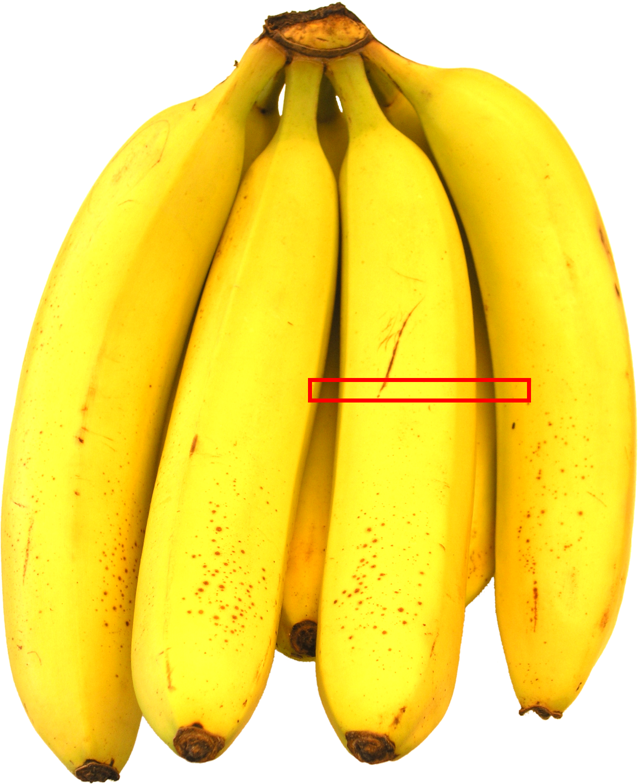

Cover and stego, zoomed 8x:


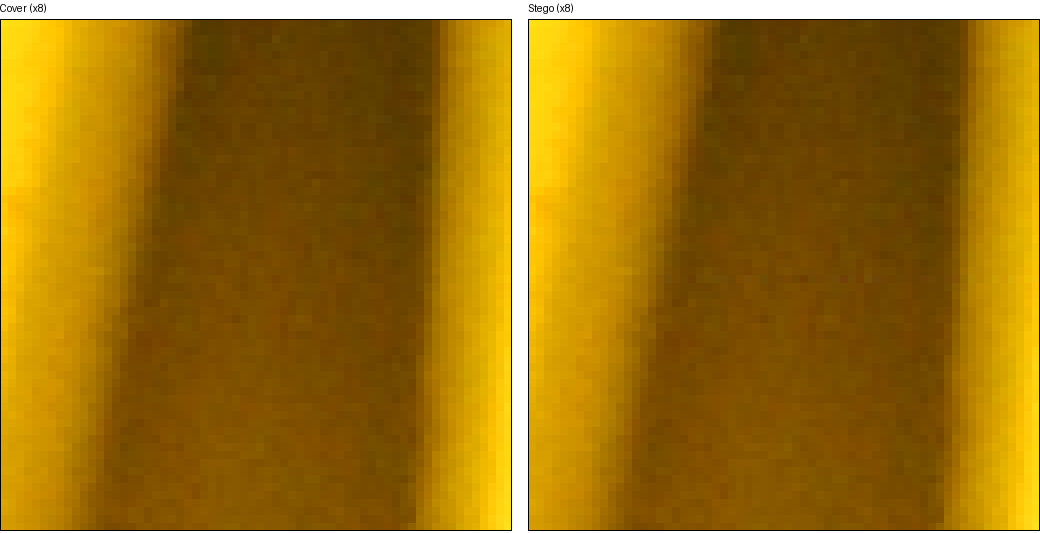

Changed-unit mask, white = changed and black = unchanged:


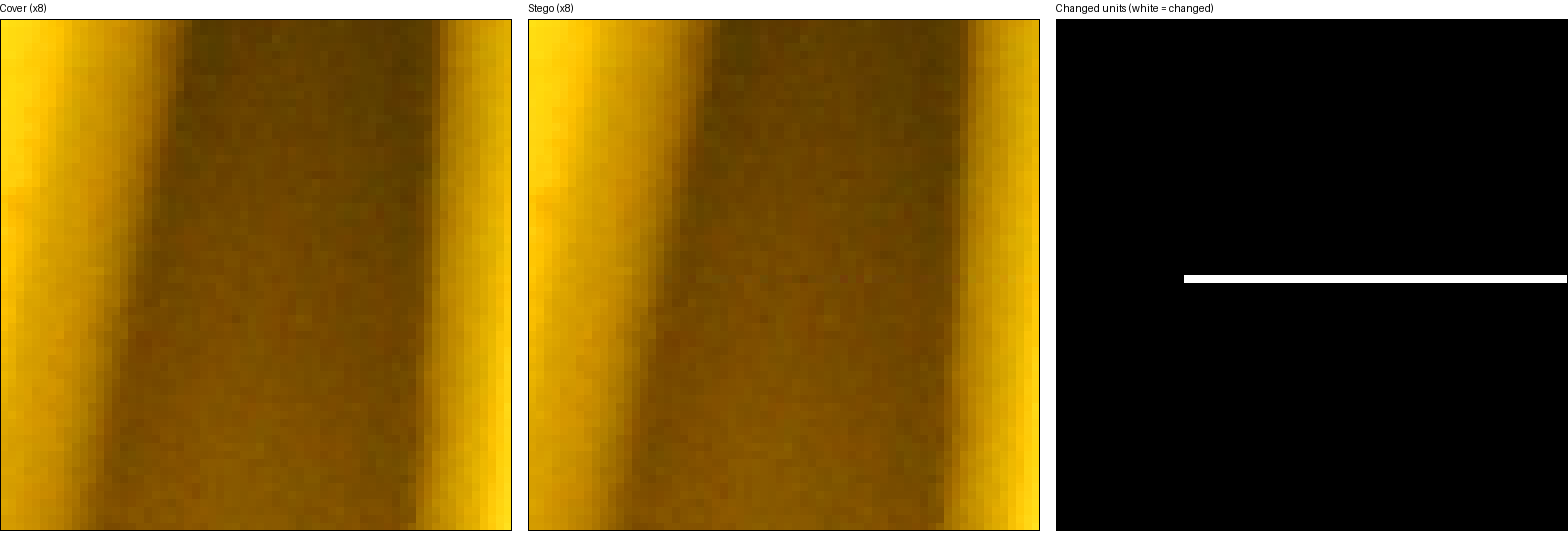

In [7]:
stego_array = load_png_from_path(stego_png_path)
stego_image = Image.fromarray(stego_array, mode="RGB")
stego_carrier = rgb_array_to_carrier(stego_array)
packet_cover_units = cover_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
packet_stego_units = stego_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
print("Stego path:", stego_png_path)
print("Stego file bytes:", stego_png_path.stat().st_size)
print("Differing pixel values:", int(np.count_nonzero(stego_array != cover_array)))
print("Cover values across packet footprint: min=", int(packet_cover_units.min()), "max=", int(packet_cover_units.max()))
print("First 8 carrier units at packet location:")
print("index | cover decimal | cover binary | stego decimal | stego binary")
for offset, (cover_value, stego_value) in enumerate(zip(packet_cover_units[:8], packet_stego_units[:8])):
    print(f"{offset:5d} | {int(cover_value):14d} | {int(cover_value):08b} | {int(stego_value):14d} | {int(stego_value):08b}")

packet_start_pixel = png_layout.start_unit // cover_array.shape[2]
packet_end_pixel = (png_layout.start_unit + png_layout.footprint - 1) // cover_array.shape[2]
packet_start_y, packet_start_x = divmod(packet_start_pixel, cover_array.shape[1])
packet_end_y, packet_end_x = divmod(packet_end_pixel, cover_array.shape[1])
packet_pixel_count = png_layout.footprint // cover_array.shape[2]
total_pixel_count = cover_array.shape[0] * cover_array.shape[1]
whole_image = cover_image.copy()
whole_draw = ImageDraw.Draw(whole_image)
packet_box = (
    max(0, packet_start_x - 24),
    max(0, packet_start_y - 24),
    min(cover_array.shape[1] - 1, packet_end_x + 24),
    min(cover_array.shape[0] - 1, max(packet_start_y, packet_end_y) + 24),
)
whole_draw.rectangle(packet_box, outline="red", width=8)
whole_display = whole_image.copy()
whole_display.thumbnail((640, 784))
print(f"Packet region: {packet_pixel_count:,} pixels of {total_pixel_count:,} ({packet_pixel_count / total_pixel_count:.2%} of the image)")
print("The red box is enlarged for visibility after downscaling.")
display(whole_display)

crop_box = (
    max(0, packet_start_x - 16),
    max(0, packet_start_y - 32),
    min(cover_array.shape[1], packet_start_x + 48),
    min(cover_array.shape[0], packet_start_y + 32),
)
cover_crop = cover_image.crop(crop_box)
stego_crop = stego_image.crop(crop_box)
print("Cover and stego, zoomed 8x:")
display(show_panels([(cover_crop, "Cover (x8)"), (stego_crop, "Stego (x8)")], scale=8))

changed_carrier = stego_carrier != cover_carrier
changed_pixel_mask = np.any(changed_carrier.reshape(cover_array.shape), axis=2)
changed_mask_image = Image.fromarray(np.where(changed_pixel_mask, 255, 0).astype(np.uint8), mode="L")
changed_crop = changed_mask_image.crop(crop_box)
print("Changed-unit mask, white = changed and black = unchanged:")
display(show_panels([(cover_crop, "Cover (x8)"), (stego_crop, "Stego (x8)"), (changed_crop, "Changed units (white = changed)")], scale=8))

### End the sender phase

The receiver gets no signing key or embedding settings. The next section starts
after those sender-only values are removed.

In [8]:
# Sender-only state is deliberately discarded before the receiver acts.
del private_key
del public_key, png_layout, png_payload, png_payload_bytes, png_signed_input
del cover_array, cover_carrier, cover_image, cover_display, stego_array, stego_image, stego_carrier
del packet_cover_units, packet_stego_units, whole_image, whole_draw, whole_display, cover_crop, stego_crop, changed_carrier, changed_pixel_mask, changed_mask_image, changed_crop
del packet_start_pixel, packet_end_pixel, packet_start_y, packet_start_x, packet_end_y, packet_end_x, packet_pixel_count, total_pixel_count, packet_box, crop_box
del start_unit, lsb_count, image_message, image_metadata

## Receiver

The receiver discovers the packet, loads the public key, and verifies the file.

### Files available to the receiver

The receiver has only the stego image path and public-key PEM path. It was never
told the start unit or LSB count.

In [9]:
print("Stego file path:", stego_png_path)
print("Public-key PEM path:", public_key_path)

Stego file path: /tmp/inf2005-demo-o5d5azk3/banana-stego.png
Public-key PEM path: /tmp/inf2005-demo-o5d5azk3/banana-public-key.pem


### Discover the packet location

The scanner searches the carrier for the start marker. Its candidates reveal the
start unit and LSB count.

In [10]:
receiver_image = load_png_from_path(stego_png_path)
receiver_carrier = rgb_array_to_carrier(receiver_image)
receiver_candidates = scan_start_magic(receiver_carrier)
print("Scanned candidates:", [{"start_unit": candidate.start_unit, "lsb_count": candidate.lsb_count} for candidate in receiver_candidates])

Scanned candidates: [{'start_unit': 2997120, 'lsb_count': 3}]


### Verify the payload

The receiver loads the public key and verifies the stego image. A valid result
returns the media ID, timestamp, and message.

In [11]:
receiver_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, receiver_public_key)
print("PNG verdict:", png_result.verdict)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))

PNG verdict: Authentic
Media ID: IMG-e7cafaeaec5f8e02210f1511dcdd4244
Timestamp: 1789209572
Recovered message: INF2005 end-to-end image demonstration


## Failure cases

Change the image or public key and compare the verdict. The untouched cover has no
packet.

In [12]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_image = load_png_from_path(stego_png_path)
altered_carrier = rgb_array_to_carrier(altered_image)
altered_carrier[-1] ^= np.uint8(1)
save_rgb_png_to_path(carrier_to_rgb_array(altered_carrier, altered_image.shape), altered_png_path)
print("Altered PNG verdict:", verify_png(altered_png_path, receiver_public_key).verdict)

actionless_private_key, wrong_public_key = generate_rsa_keypair()
del actionless_private_key
print("Wrong-key PNG verdict:", verify_png(stego_png_path, wrong_public_key).verdict)
print("Untouched cover verdict:", verify_png(sample_png_path, receiver_public_key).verdict)
del wrong_public_key, altered_image, altered_carrier

Altered PNG verdict: Tampered
Wrong-key PNG verdict: Signature Invalid


Untouched cover verdict: Payload Missing


## WAV example

The same sender/receiver flow works for a mono 8-bit PCM sine tone. The final
alteration shows tamper detection.

In [13]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (128 + 90 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype(np.uint8).tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(1)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key, wav_public_key = generate_rsa_keypair()
wav_start_unit = 61
wav_lsb_count = 5
wav_layout, wav_payload = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

# Keep the WAV receiver step independent of the sender's key and layout too.
del wav_private_key, wav_public_key, wav_layout, wav_payload, wav_samples
del wav_start_unit, wav_lsb_count
wav_receiver_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_receiver_key)
print("WAV verdict:", wav_result.verdict)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_data = load_pcm_wav_from_path(wav_stego_path)
wav_carrier = wav_frame_bytes_to_carrier(wav_data.frame_bytes)
wav_carrier[-1] ^= np.uint8(1)
save_pcm_wav_to_path(wav_data_with_carrier(wav_data, wav_carrier), wav_altered_path)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_receiver_key).verdict)
del wav_data, wav_carrier

WAV verdict: Authentic
WAV recovered message: INF2005 end-to-end audio demonstration
Altered WAV verdict: Tampered


## Analysis: compare `k=1` and `k=8`

A larger `k` uses more low bits per carrier unit and needs fewer units for the
packet. Compare the footprint and visual effect.

{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3376, 'footprint': 3376, 'changed_values': 1776, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3376, 'footprint': 422, 'changed_values': 421, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover, k=1, and k=8, labelled and downscaled for display:


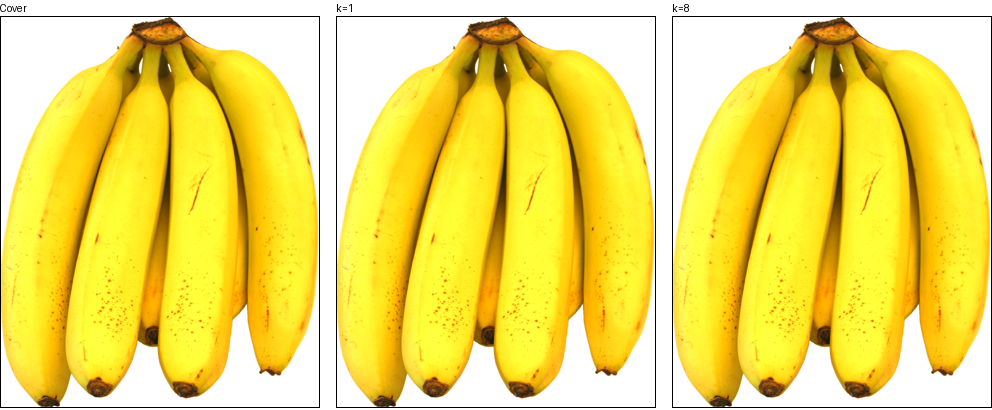

In [14]:
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_array = load_png_from_path(sample_png_path)
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        start_unit=0,
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key)
    analysis_image = np.asarray(Image.open(analysis_output), dtype=np.uint8)
    changed_values = int(np.count_nonzero(analysis_image != analysis_cover_array))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count)
    packet_bits = (PACKET_HEADER_SIZE + analysis_layout.payload_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append((analysis_preview, f"k={analysis_k}"))
for row in analysis_rows:
    print(row)
analysis_cover_preview = analysis_cover_image.copy()
analysis_cover_preview.thumbnail((320, 392))
print("Cover, k=1, and k=8, labelled and downscaled for display:")
display(show_panels([(analysis_cover_preview, "Cover"), *analysis_previews], scale=1))
del analysis_private_key, analysis_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_cover_preview

## Clean up

Generated files live in the temporary directory and are removed now.

In [15]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.
